# SEG Embedding & Representation Analysis — QM8

**Zentrale Frage:** Bestätigt sich der Frozen-vs-Learned-Befund auch für Multi-Task-Regression auf Quantenmechanik-Eigenschaften?

**QM8:**
- Multi-Task-Regression: 16 elektronische Anregungs-Eigenschaften
- ~17000+ train Moleküle (deutlich mehr als ESOL/BACE)
- Random Split für vergleichbare Evaluation

## Analysen (reduziert für Effizienz)

1. **Multi-Seed Training** — 2 Configs × 4 Seeds: xavier_frozen vs xavier_learned
2. **Effective Rank** — SVD-Analyse der Repräsentationen + Projektionsgewichte
3. **JL Distance Preservation** — Distanzerhaltung der Text-Projektion
4. **Embedding-Stabilität** — CKA über Seeds (Graph, TextProj, Fused)
5. **Tanimoto & |Δy| Correlation** — Strukturelle + task-relevante Ähnlichkeit
6. **Learning Curves** — Overfitting-Verhalten frozen vs unfrozen

In [1]:
# === Setup ===
import sys
import random
from pathlib import Path
workspace_root = Path.cwd().parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import numpy as np
import pandas as pd
import torch
import deepchem as dc
import matplotlib.pyplot as plt
from typing import Dict, List, Any
from scipy import stats
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

from utils.embedding_cache import EfficientEmbeddingCache
from utils.molecular_graph import smiles_to_graph
from utils.batched_mol_graph import batch_graphs
from models import SEGPredictor, SEGPredictorConfig

print(f"Workspace: {workspace_root}")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Workspace: c:\Users\robsc\Home\Dev\molfusion2
PyTorch: 2.6.0+cu124, CUDA: True


In [2]:
# === Load QM8 Data (Random Split) ===

tasks, datasets, transformers = dc.molnet.load_qm8(
    featurizer='ECFP',
    splitter='random',
)
train_dc, valid_dc, test_dc = datasets
QM8_TASKS = tasks  # 16 electronic properties

TRAIN_SMILES = list(train_dc.ids)
TRAIN_Y = train_dc.y.astype(np.float32)  # Normalized
VALID_SMILES = list(valid_dc.ids)
VALID_Y = valid_dc.y.astype(np.float32)
TEST_SMILES = list(test_dc.ids)
TEST_Y = test_dc.y.astype(np.float32)

# Store un-normalized labels for evaluation
TRAIN_Y_ORIG = TRAIN_Y.copy()
VALID_Y_ORIG = VALID_Y.copy()
TEST_Y_ORIG = TEST_Y.copy()
for transformer in reversed(transformers):
    TRAIN_Y_ORIG = transformer.untransform(TRAIN_Y_ORIG)
    VALID_Y_ORIG = transformer.untransform(VALID_Y_ORIG)
    TEST_Y_ORIG = transformer.untransform(TEST_Y_ORIG)
TRAIN_Y_ORIG = TRAIN_Y_ORIG.astype(np.float32)
VALID_Y_ORIG = VALID_Y_ORIG.astype(np.float32)
TEST_Y_ORIG = TEST_Y_ORIG.astype(np.float32)
TRANSFORMERS = transformers

# Text embeddings
COT_EMB_DIR = workspace_root / "cache" / "cot_embeddings"
npz_path = COT_EMB_DIR / "quantum_fast_text_embeddings_compact.npz"
cache = EfficientEmbeddingCache.load(npz_path)

all_smiles = TRAIN_SMILES + VALID_SMILES + TEST_SMILES
all_emb = torch.from_numpy(cache.get_batch(all_smiles))
n_train, n_valid = len(TRAIN_SMILES), len(VALID_SMILES)
TRAIN_TEXT_EMB = all_emb[:n_train]
VALID_TEXT_EMB = all_emb[n_train:n_train + n_valid]
TEST_TEXT_EMB = all_emb[n_train + n_valid:]

print(f"Train: {n_train} | Valid: {n_valid} | Test: {len(TEST_SMILES)}")
print(f"Tasks: {len(QM8_TASKS)} electronic properties")
print(f"Text embeddings: {TRAIN_TEXT_EMB.shape[1]}D")
print(f"Transformers: {[type(t).__name__ for t in transformers]}")
print(f"Training on NORMALIZED data; inverse-transform for MAE evaluation")

Loading embeddings from quantum_fast_text_embeddings_compact.npz...
  Loaded 21722 entries, dim=3072
  Memory mode: mapped
Train: 17397 | Valid: 2175 | Test: 2175
Tasks: 16 electronic properties
Text embeddings: 3072D
Transformers: ['NormalizationTransformer']
Training on NORMALIZED data; inverse-transform for MAE evaluation


In [3]:
# === Helper Functions ===

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def regression_metrics(y_true, y_pred, transformers=None) -> Dict[str, float]:
    """Per-task MAE in original scale."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    # Inverse-transform if transformers provided
    if transformers:
        for t in reversed(transformers):
            y_true = t.untransform(y_true)
            y_pred = t.untransform(y_pred)
    y_true = y_true.astype(np.float32)
    y_pred = y_pred.astype(np.float32)
    maes = []
    for i in range(y_true.shape[1]):
        mask = np.isfinite(y_true[:, i]) & np.isfinite(y_pred[:, i])
        if mask.sum() > 0:
            maes.append(float(np.mean(np.abs(y_true[mask, i] - y_pred[mask, i]))))
    return {"mean_mae": float(np.mean(maes)) if maes else float('inf'), "per_task_maes": maes}


def effective_rank(S: np.ndarray) -> float:
    """Entropy-based effective rank from singular values."""
    S_prob = (S**2) / np.sum(S**2)
    S_prob = S_prob[S_prob > 1e-10]
    return float(np.exp(-np.sum(S_prob * np.log(S_prob))))


def extract_graph_embeddings(model: SEGPredictor, smiles_list: List[str], batch_size: int = 64) -> np.ndarray:
    model._encoder.eval()
    model._pooling.eval()
    embeddings = []
    valid_graphs = []
    for smi in smiles_list:
        try:
            g = smiles_to_graph(smi, add_hydrogens=model.config.add_hydrogens)
            valid_graphs.append(g)
        except Exception:
            continue
    with torch.no_grad():
        for start in range(0, len(valid_graphs), batch_size):
            chunk = valid_graphs[start:start + batch_size]
            bg = batch_graphs(chunk)
            x, edge_index, edge_weight, batch = model._to_tensors(bg)
            node_emb = model._encoder(x, edge_index, edge_weight, batch)
            graph_emb = model._pooling(node_emb, batch)
            embeddings.append(graph_emb.cpu().numpy())
    return np.vstack(embeddings)


def extract_projected_text_embeddings(model: SEGPredictor, text_emb: torch.Tensor) -> np.ndarray:
    if model._text_proj is not None:
        model._text_proj.eval()
        with torch.no_grad():
            projected = model._text_proj(text_emb.to(model.device))
        return projected.cpu().numpy()
    return text_emb.numpy()


def extract_fused_embeddings(model: SEGPredictor, smiles_list: List[str],
                              text_emb: torch.Tensor, batch_size: int = 64) -> np.ndarray:
    model._encoder.eval()
    model._pooling.eval()
    model._fusion.eval()
    if model._text_proj is not None:
        model._text_proj.eval()
    embeddings = []
    valid_graphs = []
    valid_text = []
    for i, smi in enumerate(smiles_list):
        try:
            g = smiles_to_graph(smi, add_hydrogens=model.config.add_hydrogens)
            valid_graphs.append(g)
            valid_text.append(text_emb[i])
        except Exception:
            continue
    valid_text_t = torch.stack(valid_text)
    with torch.no_grad():
        for start in range(0, len(valid_graphs), batch_size):
            chunk_graphs = valid_graphs[start:start + batch_size]
            chunk_text = valid_text_t[start:start + batch_size].to(model.device)
            bg = batch_graphs(chunk_graphs)
            x, edge_index, edge_weight, batch = model._to_tensors(bg)
            node_emb = model._encoder(x, edge_index, edge_weight, batch)
            graph_emb = model._pooling(node_emb, batch)
            if model._text_proj is not None:
                chunk_text = model._text_proj(chunk_text)
            fused = model._fusion(graph_emb, chunk_text)
            embeddings.append(fused.cpu().numpy())
    return np.vstack(embeddings)


def train_and_collect(config: Dict[str, Any], seed: int, verbose: bool = False) -> Dict[str, Any]:
    """Train a model and collect all embeddings + metrics."""
    set_seed(seed)
    seg_config = SEGPredictorConfig(
        task="regression",
        num_tasks=config.get("num_tasks", 16),
        hidden_channels=config.get("hidden_channels", 128),
        K=config.get("K", 4),
        num_layers=config.get("num_layers", 3),
        dropout=config.get("dropout", 0.3),
        pool=config.get("pool", "sum"),
        set2set_processing_steps=config.get("set2set_processing_steps", 6),
        text_embedding_dim=3072,
        text_projection_dim=config.get("text_projection_dim", 64),
        text_proj_init=config.get("text_proj_init", "xavier"),
        text_proj_init_gain=config.get("text_proj_init_gain", 0.1),
        freeze_text_proj=config.get("freeze_text_proj", True),
        fusion=config.get("fusion", "cross_mha"),
        fusion_dim=config.get("fusion_dim", 64),
        fusion_n_heads=config.get("fusion_n_heads", 8),
        fusion_dropout=config.get("fusion_dropout", 0.3),
        head_type=config.get("head_type", "mlp"),
        head_hidden_dim=config.get("head_hidden_dim", 32),
        head_dropout=config.get("head_dropout", 0.6),
    )
    seg = SEGPredictor(config=seg_config)
    history = seg.fit(
        smiles_list=TRAIN_SMILES,
        labels=TRAIN_Y,
        val_smiles=VALID_SMILES,
        val_labels=VALID_Y,
        text_embeddings=TRAIN_TEXT_EMB,
        val_text_embeddings=VALID_TEXT_EMB,
        num_epochs=config.get("num_epochs", 100),
        batch_size=config.get("batch_size", 64),
        learning_rate=config.get("learning_rate", 1e-3),
        weight_decay=config.get("weight_decay", 1e-1),
        patience=config.get("patience", 15),
        scheduler=config.get("scheduler", "cosine"),
        scheduler_patience=config.get("scheduler_patience", 5),
        scheduler_factor=config.get("scheduler_factor", 0.5),
        min_lr=config.get("min_lr", 1e-6),
        grad_clip=config.get("grad_clip", None),
        seed=seed,
        verbose=verbose,
    )
    # Test metrics (in normalized space + inverse transform)
    preds_norm = seg.predict_batch(TEST_SMILES, text_embeddings=TEST_TEXT_EMB)
    metrics = regression_metrics(TEST_Y, preds_norm, transformers=TRANSFORMERS)
    # Extract embeddings on test set
    graph_emb = extract_graph_embeddings(seg, TEST_SMILES)
    text_proj_emb = extract_projected_text_embeddings(seg, TEST_TEXT_EMB)
    fused_emb = extract_fused_embeddings(seg, TEST_SMILES, TEST_TEXT_EMB)
    # SVD analysis
    _, S_graph, _ = np.linalg.svd(graph_emb, full_matrices=False)
    _, S_text_proj, _ = np.linalg.svd(text_proj_emb, full_matrices=False)
    _, S_fused, _ = np.linalg.svd(fused_emb, full_matrices=False)
    # Text projection weight SVD
    text_proj_weight_S = None
    if seg._text_proj is not None:
        W = seg._text_proj[0].weight.detach().cpu().numpy()
        _, text_proj_weight_S, _ = np.linalg.svd(W, full_matrices=False)
    return {
        "seed": seed, "metrics": metrics, "history": history, "model": seg,
        "graph_emb": graph_emb, "text_proj_emb": text_proj_emb, "fused_emb": fused_emb,
        "S_graph": S_graph, "S_text_proj": S_text_proj, "S_fused": S_fused,
        "text_proj_weight_S": text_proj_weight_S,
    }


print("\u2713 Helper functions loaded")


✓ Helper functions loaded


---
## 0. Baseline Comparison

| Modell | Beschreibung |
|--------|-------------|
| RF (ECFP+Desc) | Multi-Output Random Forest auf ECFP-Counts + 217 RDKit-Deskriptoren |
| Text MLP | Multi-Output MLP auf 3072D LLM-Embeddings (MSE, normalisiert) |
| SEG frozen / learned | Vollständiges Modell mit/ohne freeze_text_proj |

**Hinweis:** ChebPredictor unterstützt nur single-task → wird bei 16-Task-QM8 übersprungen.
RF trainiert auf Original-Skala, TextMLP auf normalisierter Skala (wie SEG). MAE wird auf Original-Skala evaluiert.

Computing molecular features...


[02:59:50] WARNING: not removing hydrogen atom without neighbors
[02:59:50] WARNING: not removing hydrogen atom without neighbors
[03:00:00] WARNING: not removing hydrogen atom without neighbors
[03:00:00] WARNING: not removing hydrogen atom without neighbors
[03:00:10] WARNING: not removing hydrogen atom without neighbors
[03:00:10] WARNING: not removing hydrogen atom without neighbors
[03:00:11] WARNING: not removing hydrogen atom without neighbors
[03:00:11] WARNING: not removing hydrogen atom without neighbors
[03:00:12] WARNING: not removing hydrogen atom without neighbors
[03:00:12] WARNING: not removing hydrogen atom without neighbors
[03:00:13] WARNING: not removing hydrogen atom without neighbors
[03:00:13] WARNING: not removing hydrogen atom without neighbors
[03:00:15] WARNING: not removing hydrogen atom without neighbors
[03:00:15] WARNING: not removing hydrogen atom without neighbors
[03:00:17] WARNING: not removing hydrogen atom without neighbors
[03:00:17] WARNING: not r

Features: ECFP=2048 + Desc=217 = 2265
  RF seed=42: Mean MAE=0.033634
  RF seed=113: Mean MAE=0.033589
  RF seed=456: Mean MAE=0.033611
  RF seed=789: Mean MAE=0.033634
  RF Mean: 0.033617±0.000018

  TextMLP seed=42: Mean MAE=0.039873
  TextMLP seed=113: Mean MAE=0.039862
  TextMLP seed=456: Mean MAE=0.039909
  TextMLP seed=789: Mean MAE=0.039927
  TextMLP Mean: 0.039893±0.000026



[03:01:54] WARNING: not removing hydrogen atom without neighbors
[03:01:55] WARNING: not removing hydrogen atom without neighbors
[03:01:55] WARNING: not removing hydrogen atom without neighbors
[03:01:55] WARNING: not removing hydrogen atom without neighbors
[03:01:55] WARNING: not removing hydrogen atom without neighbors
[03:01:55] WARNING: not removing hydrogen atom without neighbors
[03:01:55] WARNING: not removing hydrogen atom without neighbors
[03:01:55] WARNING: not removing hydrogen atom without neighbors
[03:01:56] WARNING: not removing hydrogen atom without neighbors
[03:01:56] WARNING: not removing hydrogen atom without neighbors
[03:01:56] WARNING: not removing hydrogen atom without neighbors
[03:01:56] WARNING: not removing hydrogen atom without neighbors
[03:01:56] WARNING: not removing hydrogen atom without neighbors
[03:01:56] WARNING: not removing hydrogen atom without neighbors
[03:01:56] WARNING: not removing hydrogen atom without neighbors
[03:01:56] WARNING: not r

  SEG frozen seed=42: MAE=0.030610


...

  SEG learned seed=42: MAE=0.031078


[03:12:51] WARNING: not removing hydrogen atom without neighbors
[03:12:51] WARNING: not removing hydrogen atom without neighbors
[03:12:51] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not removing hydrogen atom without neighbors
[03:12:52] WARNING: not r

  SEG frozen seed=113: MAE=0.030769


[03:18:23] WARNING: not removing hydrogen atom without neighbors
[03:18:23] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not removing hydrogen atom without neighbors
[03:18:24] WARNING: not r

  SEG learned seed=113: MAE=0.031026

BASELINE COMPARISON — QM8 Random Split (Multi-Task Regression)

Model                                  Mean MAE    n
------------------------------------------------------
  Random Forest (ECFP+Desc)  0.033617±0.000018     4
  Text MLP only (LLM)        0.039893±0.000026     4
  SEG (frozen text_proj)     0.030689±0.000080     2
  SEG (learned text_proj)    0.031052±0.000026     2

  (ChebNet only: skipped — single-task model, incompatible with 16-task QM8)


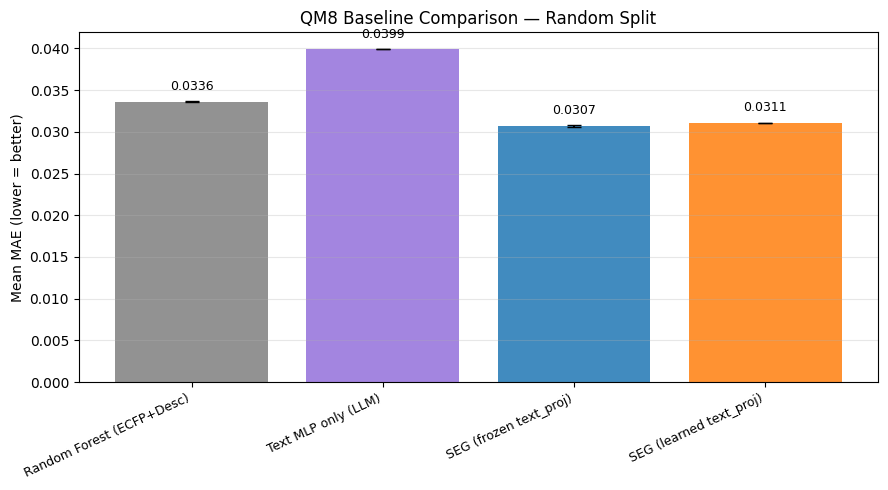

In [4]:
# === Baseline Comparison: RF, Text-MLP, SEG ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

BASELINE_SEEDS = [42, 113, 456, 789]
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_features(smiles_list):
    """ECFP count fingerprints + RDKit 2D descriptors."""
    desc_names = [name for name, _ in Descriptors.descList]
    fps, descs = [], []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = morgan_gen.GetCountFingerprint(mol)
            fps.append(np.array([fp[i] for i in range(2048)], dtype=np.float32))
            all_d = Descriptors.CalcMolDescriptors(mol)
            desc_vals = []
            for name in desc_names:
                try:
                    val = float(all_d.get(name, 0.0))
                    desc_vals.append(val if np.isfinite(val) else 0.0)
                except (TypeError, ValueError):
                    desc_vals.append(0.0)
            descs.append(desc_vals)
        else:
            fps.append(np.zeros(2048, dtype=np.float32))
            descs.append([0.0] * len(desc_names))
    desc_arr = np.array(descs, dtype=np.float32)
    desc_arr = np.nan_to_num(desc_arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.array(fps), desc_arr

print("Computing molecular features...")
train_fps, train_descs = smiles_to_features(TRAIN_SMILES)
valid_fps, valid_descs = smiles_to_features(VALID_SMILES)
test_fps_arr, test_descs = smiles_to_features(TEST_SMILES)

desc_scaler = StandardScaler()
train_descs_s = desc_scaler.fit_transform(train_descs)
valid_descs_s = desc_scaler.transform(valid_descs)
test_descs_s = desc_scaler.transform(test_descs)
train_X = np.hstack([train_fps, train_descs_s])
valid_X = np.hstack([valid_fps, valid_descs_s])
test_X = np.hstack([test_fps_arr, test_descs_s])
print(f"Features: ECFP={train_fps.shape[1]} + Desc={train_descs.shape[1]} = {train_X.shape[1]}")

# --- 1. Random Forest (multi-output, original scale) ---
rf_results = []
for seed in BASELINE_SEEDS:
    rf = RandomForestRegressor(n_estimators=500, max_features="sqrt",
                               min_samples_leaf=2, random_state=seed, n_jobs=-1)
    rf.fit(train_X, TRAIN_Y_ORIG)
    preds = rf.predict(test_X)
    maes = [float(np.mean(np.abs(preds[:, i] - TEST_Y_ORIG[:, i]))) for i in range(preds.shape[1])]
    rf_results.append(float(np.mean(maes)))
    print(f"  RF seed={seed}: Mean MAE={rf_results[-1]:.6f}")
print(f"  RF Mean: {np.mean(rf_results):.6f}±{np.std(rf_results):.6f}\n")

# --- 2. Text MLP only (multi-output MSE, normalized) ---
class TextMLP(torch.nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=128, num_tasks=16, dropout=0.5):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim), torch.nn.ReLU(), torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, hidden_dim // 2), torch.nn.ReLU(), torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim // 2, num_tasks),
        )
    def forward(self, x): return self.net(x)

text_results = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for seed in BASELINE_SEEDS:
    set_seed(seed)
    mlp = TextMLP(num_tasks=TRAIN_Y.shape[1]).to(device)
    opt = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-1)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    tx = TRAIN_TEXT_EMB.to(device)
    ty = torch.tensor(TRAIN_Y, device=device)
    vx = VALID_TEXT_EMB.to(device)
    vy = torch.tensor(VALID_Y, device=device)
    best_val, pat_ctr, best_st = float("inf"), 0, None
    for ep in range(100):
        mlp.train(); perm = torch.randperm(len(tx))
        for s in range(0, len(tx), 64):
            idx = perm[s:s+64]
            loss = torch.nn.functional.mse_loss(mlp(tx[idx]), ty[idx])
            opt.zero_grad(); loss.backward(); opt.step()
        mlp.eval()
        with torch.no_grad():
            vl = float(torch.nn.functional.mse_loss(mlp(vx), vy))
        sched.step(vl)
        if vl < best_val:
            best_val, best_st, pat_ctr = vl, {k: v.clone() for k, v in mlp.state_dict().items()}, 0
        else:
            pat_ctr += 1
            if pat_ctr >= 15: break
    mlp.load_state_dict(best_st); mlp.eval()
    with torch.no_grad():
        tp = mlp(TEST_TEXT_EMB.to(device)).cpu().numpy()
    m = regression_metrics(TEST_Y, tp, transformers=TRANSFORMERS)
    text_results.append(m["mean_mae"])
    print(f"  TextMLP seed={seed}: Mean MAE={m['mean_mae']:.6f}")
print(f"  TextMLP Mean: {np.mean(text_results):.6f}±{np.std(text_results):.6f}\n")

# --- 3. SEG frozen & learned ---
seg_frozen_results, seg_learned_results = [], []
_has = "ALL_RESULTS" in dir() and isinstance(ALL_RESULTS, dict) and \
    "xavier_frozen" in ALL_RESULTS and len(ALL_RESULTS.get("xavier_frozen", {})) >= 2
if _has:
    for seed in list(ALL_RESULTS["xavier_frozen"].keys()):
        seg_frozen_results.append(ALL_RESULTS["xavier_frozen"][seed]["metrics"]["mean_mae"])
        seg_learned_results.append(ALL_RESULTS["xavier_learned"][seed]["metrics"]["mean_mae"])
    print("  (Reusing SEG results from main experiments)")
else:
    _seg_base = {
        "hidden_channels": 256, "K": 4, "num_layers": 3, "pool": "sum",
        "set2set_processing_steps": 6, "num_tasks": 16,
        "fusion": "cross_mha", "fusion_dim": 64, "fusion_n_heads": 8,
        "text_projection_dim": 64,
        "dropout": 0.3, "fusion_dropout": 0.3, "head_dropout": 0.3,
        "weight_decay": 1e-1, "head_type": "mlp", "head_hidden_dim": 32,
        "learning_rate": 1e-3, "batch_size": 64, "num_epochs": 100, "patience": 20,
        "scheduler": "cosine", "scheduler_patience": 5, "scheduler_factor": 0.5,
        "min_lr": 1e-6, "grad_clip": None,
    }
    for seed in BASELINE_SEEDS[:2]:
        for cn, fr in [("frozen", True), ("learned", False)]:
            r = train_and_collect({**_seg_base, "text_proj_init": "xavier",
                "text_proj_init_gain": 0.1, "freeze_text_proj": fr}, seed, verbose=False)
            (seg_frozen_results if fr else seg_learned_results).append(r["metrics"]["mean_mae"])
            print(f"  SEG {cn} seed={seed}: MAE={r['metrics']['mean_mae']:.6f}")

# === Summary ===
print("\n" + "=" * 65)
print("BASELINE COMPARISON — QM8 Random Split (Multi-Task Regression)")
print("=" * 65)
baselines = {
    "Random Forest (ECFP+Desc)": rf_results,
    "Text MLP only (LLM)": text_results,
    "SEG (frozen text_proj)": seg_frozen_results,
    "SEG (learned text_proj)": seg_learned_results,
}
print(f"\n{'Model':<28} {'Mean MAE':>18} {'n':>4}")
print("-" * 54)
for name, res in baselines.items():
    print(f"  {name:<26} {np.mean(res):.6f}±{np.std(res):.6f}  {len(res):>4}")
print("\n  (ChebNet only: skipped — single-task model, incompatible with 16-task QM8)")

fig, ax = plt.subplots(figsize=(9, 5))
names = list(baselines.keys())
means = [np.mean(v) for v in baselines.values()]
stds = [np.std(v) for v in baselines.values()]
bar_colors = ["#7f7f7f", "mediumpurple", "tab:blue", "tab:orange"]
ax.bar(range(len(names)), means, yerr=stds, capsize=5, color=bar_colors, alpha=0.85)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Mean MAE (lower = better)")
ax.set_title("QM8 Baseline Comparison — Random Split")
ax.grid(alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.001, f"{m:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()
print()

---
## 1. Multi-Seed Training — 2 Configs × 4 Seeds

| Label | `text_proj_init` | `freeze_text_proj` |
|-------|-----------------|-------------------|
| **xavier_frozen** | xavier | True |
| **xavier_learned** | xavier | False |

Base-Config aus QM8-Benchmark: `hidden_channels=128, K=4, num_layers=3, sum, fusion_dim=64, text_proj_dim=64, head_hidden_dim=32, cosine scheduler, patience=15, batch=64`.

In [5]:
# === Train 2 Configs × 4 Seeds ===
SEEDS = [42, 113]
BASE_CONFIG = {
    "hidden_channels": 256, "K": 4, "num_layers": 3, "pool": "sum",
    "set2set_processing_steps": 6,
    "fusion": "cross_mha", "fusion_dim": 64, "fusion_n_heads": 8,
    "text_projection_dim": 64, "num_tasks": 16,
    "dropout": 0.3, "fusion_dropout": 0.3, "head_dropout": 0.3,
    "weight_decay": 1e-1, "head_type": "mlp", "head_hidden_dim": 32,
    "learning_rate": 1e-3, "batch_size": 64, "num_epochs": 100, "patience": 20,
    "scheduler": "cosine", "scheduler_patience": 5, "scheduler_factor": 0.5,
    "min_lr": 1e-6, "grad_clip": None,
}

CONFIGS = {
    "xavier_frozen":  {**BASE_CONFIG, "text_proj_init": "xavier", "text_proj_init_gain": 0.1, "freeze_text_proj": True},
    "xavier_learned": {**BASE_CONFIG, "text_proj_init": "xavier", "text_proj_init_gain": 0.1, "freeze_text_proj": False},
}

ALL_RESULTS = {}
n_total = len(CONFIGS) * len(SEEDS)
counter = 0

for config_name, config in CONFIGS.items():
    ALL_RESULTS[config_name] = {}
    print(f"\n{'='*60}")
    print(f"CONFIG: {config_name}")
    print(f"{'='*60}")
    for seed in SEEDS:
        counter += 1
        print(f"  [{counter}/{n_total}] seed={seed}...", end=" ", flush=True)
        result = train_and_collect(config, seed, verbose=False)
        ALL_RESULTS[config_name][seed] = result
        m = result["metrics"]
        print(f"Mean MAE={m['mean_mae']*1000:.4f}e-3")

print(f"\n\u2713 All {n_total} experiments complete.")



CONFIG: xavier_frozen
  [1/4] seed=42... 

[03:24:11] WARNING: not removing hydrogen atom without neighbors
[03:24:11] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not removing hydrogen atom without neighbors
[03:24:12] WARNING: not r

Mean MAE=30.8177e-3
  [2/4] seed=113... 

[03:29:45] WARNING: not removing hydrogen atom without neighbors
[03:29:46] WARNING: not removing hydrogen atom without neighbors
[03:29:46] WARNING: not removing hydrogen atom without neighbors
[03:29:46] WARNING: not removing hydrogen atom without neighbors
[03:29:46] WARNING: not removing hydrogen atom without neighbors
[03:29:46] WARNING: not removing hydrogen atom without neighbors
[03:29:46] WARNING: not removing hydrogen atom without neighbors
[03:29:46] WARNING: not removing hydrogen atom without neighbors
[03:29:46] WARNING: not removing hydrogen atom without neighbors
[03:29:46] WARNING: not removing hydrogen atom without neighbors
[03:29:46] WARNING: not removing hydrogen atom without neighbors
[03:29:47] WARNING: not removing hydrogen atom without neighbors
[03:29:47] WARNING: not removing hydrogen atom without neighbors
[03:29:47] WARNING: not removing hydrogen atom without neighbors
[03:29:47] WARNING: not removing hydrogen atom without neighbors
[03:29:47] WARNING: not r

Mean MAE=30.7723e-3

CONFIG: xavier_learned
  [3/4] seed=42... 

[03:35:33] WARNING: not removing hydrogen atom without neighbors
[03:35:33] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not removing hydrogen atom without neighbors
[03:35:34] WARNING: not r

Mean MAE=31.3235e-3
  [4/4] seed=113... 

[03:41:07] WARNING: not removing hydrogen atom without neighbors
[03:41:07] WARNING: not removing hydrogen atom without neighbors
[03:41:07] WARNING: not removing hydrogen atom without neighbors
[03:41:07] WARNING: not removing hydrogen atom without neighbors
[03:41:07] WARNING: not removing hydrogen atom without neighbors
[03:41:07] WARNING: not removing hydrogen atom without neighbors
[03:41:08] WARNING: not removing hydrogen atom without neighbors
[03:41:08] WARNING: not removing hydrogen atom without neighbors
[03:41:08] WARNING: not removing hydrogen atom without neighbors
[03:41:08] WARNING: not removing hydrogen atom without neighbors
[03:41:08] WARNING: not removing hydrogen atom without neighbors
[03:41:08] WARNING: not removing hydrogen atom without neighbors
[03:41:08] WARNING: not removing hydrogen atom without neighbors
[03:41:08] WARNING: not removing hydrogen atom without neighbors
[03:41:08] WARNING: not removing hydrogen atom without neighbors
[03:41:08] WARNING: not r

Mean MAE=31.0456e-3

✓ All 4 experiments complete.


In [6]:
# === Metriken-Übersicht ===
rows = []
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        rows.append({"config": config_name, "seed": seed, "mean_mae": r["metrics"]["mean_mae"]})

metrics_df = pd.DataFrame(rows)

summary = metrics_df.groupby("config").agg(
    mae_mean=("mean_mae", "mean"), mae_std=("mean_mae", "std"),
    n=("mean_mae", "count"),
).sort_values("mae_mean", ascending=True)

print("=== AGGREGATED RESULTS (sorted by Mean MAE, lower=better) ===\n")
for config_name, row in summary.iterrows():
    print(f"  {config_name:<20} Mean MAE={row['mae_mean']*1000:.4f}\u00b1{row['mae_std']*1000:.4f} (\u00d71e-3)  (n={int(row['n'])})")

summary


=== AGGREGATED RESULTS (sorted by Mean MAE, lower=better) ===

  xavier_frozen        Mean MAE=30.7950±0.0321 (×1e-3)  (n=2)
  xavier_learned       Mean MAE=31.1846±0.1965 (×1e-3)  (n=2)


,mae_mean,mae_std,n
config,,,
xavier_frozen,0.030795,0.000032,2
xavier_learned,0.031185,0.000196,2


---
## 2. Effective Rank Analysis

SVD-basierte Analyse der Repräsentations-Dimensionalität.  
**Daten-Rang** (Graph, TextProj-Daten, Fused) separat vom **Gewichts-Rang** (Proj.W).


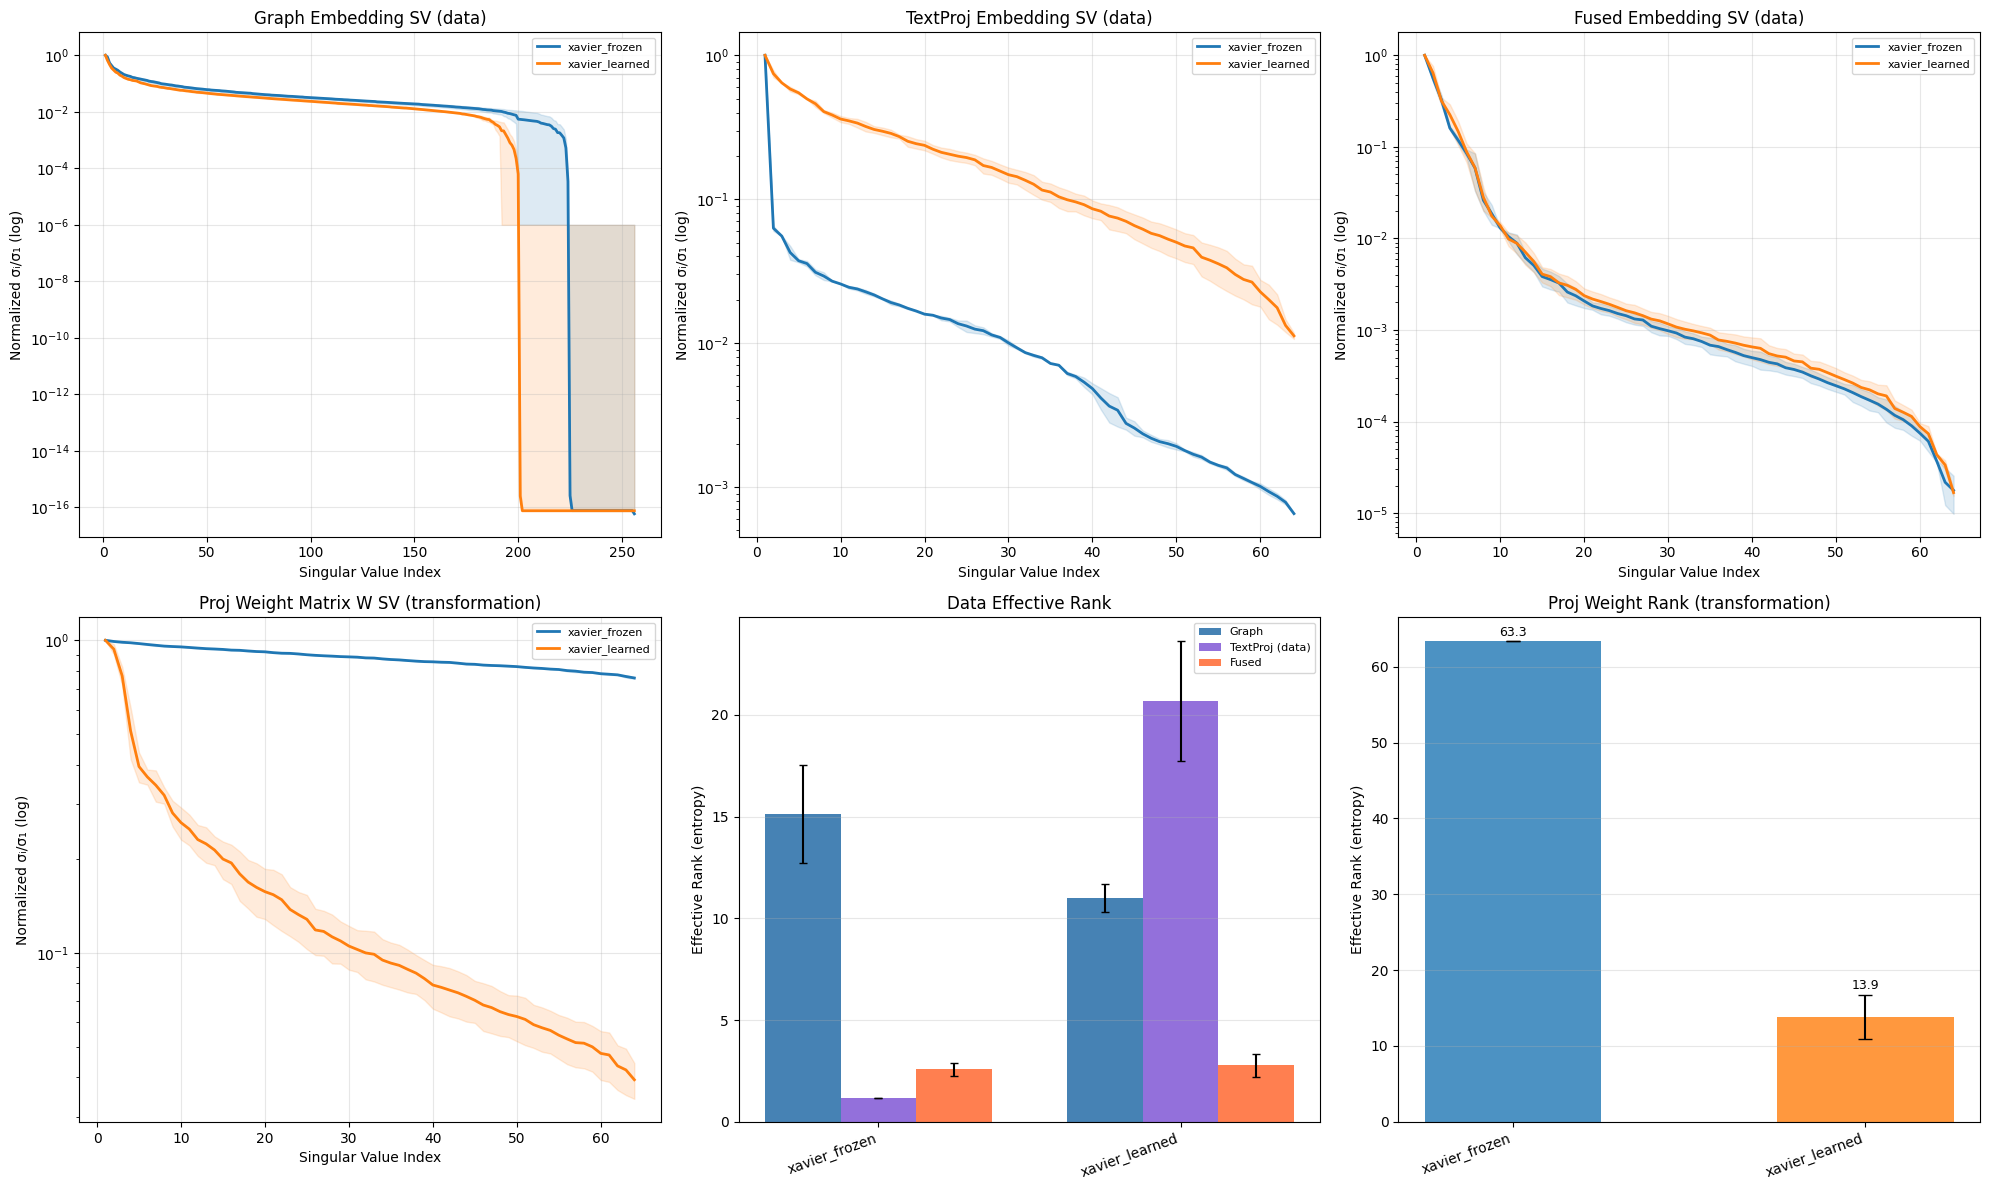


=== EFFECTIVE RANK SUMMARY ===

Config                Graph(data)  TextProj(data)  Fused(data)  Proj.W(weight)
--------------------------------------------------------------------------------
xavier_frozen         15.1±2.4       1.2±0.0     2.6±0.3          63.3±0.0
xavier_learned        11.0±0.7      20.7±2.9     2.8±0.6          13.9±2.9

Max possible: graph=256, text_proj=64, proj_w=64


In [7]:
# === Effective Rank: Graph, TextProj-Data, Fused + Proj Weights ===
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
colors = {"xavier_frozen": "tab:blue", "xavier_learned": "tab:orange"}
config_order = ["xavier_frozen", "xavier_learned"]

rank_summary = []
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        eff_rank_graph = effective_rank(r["S_graph"])
        eff_rank_text = effective_rank(r["S_text_proj"])
        eff_rank_fused = effective_rank(r["S_fused"])
        eff_rank_proj_w = effective_rank(r["text_proj_weight_S"]) if r["text_proj_weight_S"] is not None else None
        rank_summary.append({
            "config": config_name, "seed": seed,
            "eff_rank_graph": eff_rank_graph, "eff_rank_text": eff_rank_text,
            "eff_rank_fused": eff_rank_fused, "eff_rank_proj_w": eff_rank_proj_w,
        })

# --- Plot 1: Graph Embedding SV ---
ax = axes[0, 0]
for config_name in config_order:
    seed_results = ALL_RESULTS[config_name]
    all_S = np.array([r["S_graph"] / r["S_graph"][0] for r in seed_results.values()])
    mean_S, std_S = all_S.mean(0), all_S.std(0)
    x = np.arange(1, len(mean_S) + 1)
    ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
    ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S,
                     color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized \u03c3\u1d62/\u03c3\u2081 (log)")
ax.set_title("Graph Embedding SV (data)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Plot 2: TextProj Embedding SV (DATA) ---
ax = axes[0, 1]
for config_name in config_order:
    seed_results = ALL_RESULTS[config_name]
    all_S = np.array([r["S_text_proj"] / r["S_text_proj"][0] for r in seed_results.values()])
    mean_S, std_S = all_S.mean(0), all_S.std(0)
    x = np.arange(1, len(mean_S) + 1)
    ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
    ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S,
                     color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized \u03c3\u1d62/\u03c3\u2081 (log)")
ax.set_title("TextProj Embedding SV (data)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Plot 3: Fused Embedding SV ---
ax = axes[0, 2]
for config_name in config_order:
    seed_results = ALL_RESULTS[config_name]
    all_S = np.array([r["S_fused"] / r["S_fused"][0] for r in seed_results.values()])
    mean_S, std_S = all_S.mean(0), all_S.std(0)
    x = np.arange(1, len(mean_S) + 1)
    ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
    ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S,
                     color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized \u03c3\u1d62/\u03c3\u2081 (log)")
ax.set_title("Fused Embedding SV (data)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Plot 4: Proj Weight Matrix SV ---
ax = axes[1, 0]
for config_name in config_order:
    seed_results = ALL_RESULTS[config_name]
    S_arrays = [r["text_proj_weight_S"] for r in seed_results.values() if r["text_proj_weight_S"] is not None]
    if S_arrays:
        all_S = np.array([S / S[0] for S in S_arrays])
        mean_S, std_S = all_S.mean(0), all_S.std(0)
        x = np.arange(1, len(mean_S) + 1)
        ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
        ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S,
                         color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized \u03c3\u1d62/\u03c3\u2081 (log)")
ax.set_title("Proj Weight Matrix W SV (transformation)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Plot 5: Data Effective Rank Bar Chart ---
ax = axes[1, 1]
rank_df = pd.DataFrame(rank_summary)
rank_agg = rank_df.groupby("config").agg(
    graph_mean=("eff_rank_graph", "mean"), graph_std=("eff_rank_graph", "std"),
    text_mean=("eff_rank_text", "mean"), text_std=("eff_rank_text", "std"),
    fused_mean=("eff_rank_fused", "mean"), fused_std=("eff_rank_fused", "std"),
).reindex(config_order)
x = np.arange(len(rank_agg))
width = 0.25
ax.bar(x - width, rank_agg["graph_mean"], width, yerr=rank_agg["graph_std"],
       label="Graph", color="steelblue", capsize=3)
ax.bar(x, rank_agg["text_mean"], width, yerr=rank_agg["text_std"],
       label="TextProj (data)", color="mediumpurple", capsize=3)
ax.bar(x + width, rank_agg["fused_mean"], width, yerr=rank_agg["fused_std"],
       label="Fused", color="coral", capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(rank_agg.index, rotation=20, ha="right")
ax.set_ylabel("Effective Rank (entropy)")
ax.set_title("Data Effective Rank")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

# --- Plot 6: Weight Effective Rank Bar Chart ---
ax = axes[1, 2]
rank_agg_w = rank_df.groupby("config").agg(
    proj_w_mean=("eff_rank_proj_w", "mean"), proj_w_std=("eff_rank_proj_w", "std"),
).reindex(config_order)
ax.bar(x, rank_agg_w["proj_w_mean"], 0.5, yerr=rank_agg_w["proj_w_std"],
       color=[colors[c] for c in config_order], capsize=5, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(config_order, rotation=20, ha="right")
ax.set_ylabel("Effective Rank (entropy)")
ax.set_title("Proj Weight Rank (transformation)")
ax.grid(alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(rank_agg_w["proj_w_mean"], rank_agg_w["proj_w_std"])):
    if not np.isnan(m):
        ax.text(i, m + s + 0.3, f"{m:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
print("\n=== EFFECTIVE RANK SUMMARY ===\n")
print(f"{'Config':<20} {'Graph(data)':>12} {'TextProj(data)':>15} {'Fused(data)':>12} {'Proj.W(weight)':>15}")
print("-" * 80)
for c in config_order:
    rg = rank_agg.loc[c]
    rw = rank_agg_w.loc[c]
    pw_str = f"{rw['proj_w_mean']:.1f}\u00b1{rw['proj_w_std']:.1f}" if not np.isnan(rw['proj_w_mean']) else "N/A"
    print(f"{c:<20} {rg['graph_mean']:>5.1f}\u00b1{rg['graph_std']:<4.1f}  "
          f"{rg['text_mean']:>7.1f}\u00b1{rg['text_std']:<4.1f}  "
          f"{rg['fused_mean']:>5.1f}\u00b1{rg['fused_std']:<4.1f}  "
          f"{pw_str:>15}")
print(f"\nMax possible: graph={BASE_CONFIG['hidden_channels']}, "
      f"text_proj={BASE_CONFIG['text_projection_dim']}, proj_w={BASE_CONFIG['text_projection_dim']}")


---
### 2b. Johnson-Lindenstrauss Distance Preservation Test

Bleiben paarweise Distanzen bei der Projektion 3072D → 64D erhalten?  
Zusätzlich: Trainable-Parameter-Vergleich.


Original text embeddings: (2175, 3072)
Subsample for JL: 500 molecules, 124750 pairs



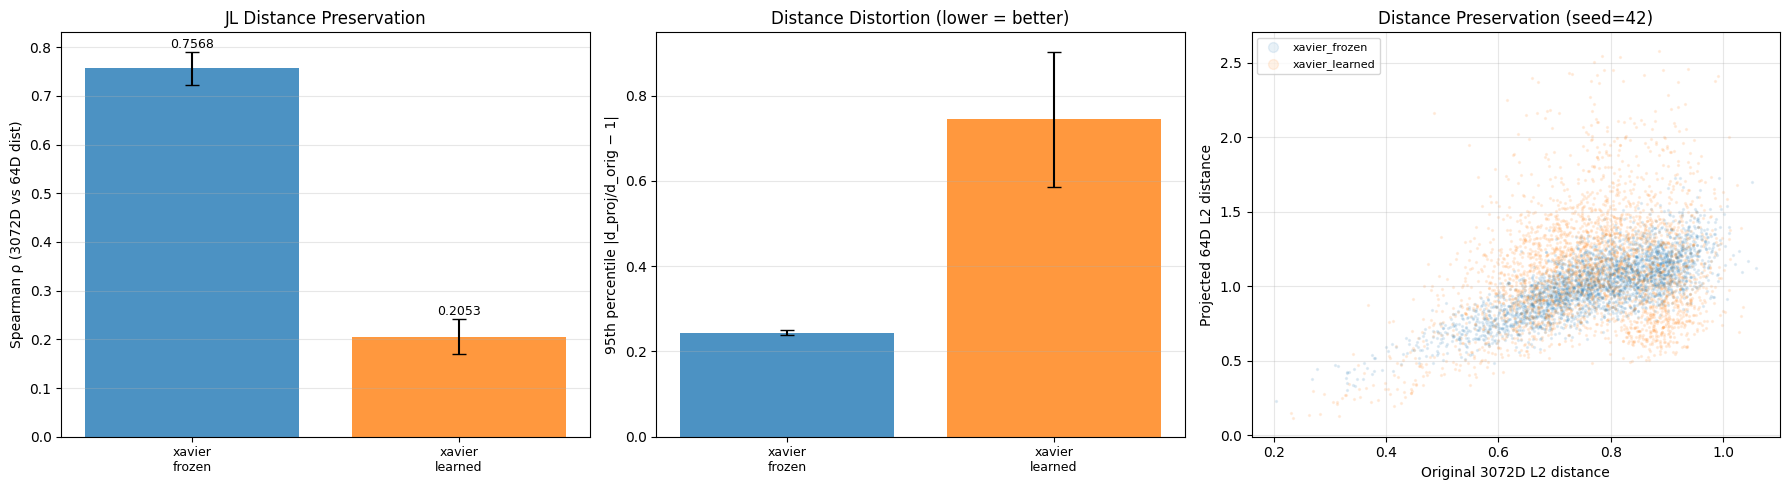


=== TRAINABLE PARAMETER COUNT ===

  xavier_frozen        total= 819,696  trainable= 622,896  frozen= 196,800  (76% trainable)
  xavier_learned       total= 819,696  trainable= 819,696  frozen=       0  (100% trainable)

=== JL DISTANCE PRESERVATION SUMMARY ===

Config                   Spearman ρ   95% Distortion
-------------------------------------------------------
  xavier_frozen        0.7568±0.0341   0.244±0.005
  xavier_learned       0.2053±0.0357   0.744±0.159


In [8]:
# === JL Distance Preservation + Parameter Count ===

# --- 1. Pairwise distances in original 3072D ---
# Use a subsample for QM8 since test set may be large
text_emb_np = TEST_TEXT_EMB.numpy()
n_sub = min(len(text_emb_np), 500)  # Limit pairs for speed
np.random.seed(42)
sub_idx = np.random.choice(len(text_emb_np), n_sub, replace=False)
text_emb_sub = text_emb_np[sub_idx]
dist_original = pdist(text_emb_sub, metric="euclidean")
print(f"Original text embeddings: {text_emb_np.shape}")
print(f"Subsample for JL: {n_sub} molecules, {len(dist_original)} pairs\n")

# --- 2. Compare projected distances ---
jl_results = []
config_order = ["xavier_frozen", "xavier_learned"]
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        proj_emb = r["text_proj_emb"][sub_idx]
        dist_proj = pdist(proj_emb, metric="euclidean")
        rho, pval = spearmanr(dist_original, dist_proj)
        ratio = dist_proj / (dist_original + 1e-10)
        median_ratio = np.median(ratio)
        normalized = ratio / median_ratio
        p95_distortion = np.percentile(np.abs(normalized - 1.0), 95)
        jl_results.append({
            "config": config_name, "seed": seed,
            "spearman_rho": rho, "p95_distortion": p95_distortion,
        })

jl_df = pd.DataFrame(jl_results)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
means = [jl_df[jl_df["config"] == c]["spearman_rho"].mean() for c in config_order]
stds = [jl_df[jl_df["config"] == c]["spearman_rho"].std() for c in config_order]
ax.bar(range(2), means, yerr=stds, capsize=5,
       color=[colors[c] for c in config_order], alpha=0.8)
ax.set_xticks(range(2))
ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=9)
ax.set_ylabel("Spearman \u03c1 (3072D vs 64D dist)")
ax.set_title("JL Distance Preservation")
ax.grid(alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.002, f"{m:.4f}", ha="center", va="bottom", fontsize=9)

ax = axes[1]
means = [jl_df[jl_df["config"] == c]["p95_distortion"].mean() for c in config_order]
stds = [jl_df[jl_df["config"] == c]["p95_distortion"].std() for c in config_order]
ax.bar(range(2), means, yerr=stds, capsize=5,
       color=[colors[c] for c in config_order], alpha=0.8)
ax.set_xticks(range(2))
ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=9)
ax.set_ylabel("95th percentile |d_proj/d_orig \u2212 1|")
ax.set_title("Distance Distortion (lower = better)")
ax.grid(alpha=0.3, axis="y")

ax = axes[2]
seed0 = SEEDS[0]
for config_name in config_order:
    r = ALL_RESULTS[config_name][seed0]
    dist_proj = pdist(r["text_proj_emb"][sub_idx], metric="euclidean")
    n_pairs = len(dist_original)
    idx_sub = np.random.choice(n_pairs, min(3000, n_pairs), replace=False)
    ax.scatter(dist_original[idx_sub], dist_proj[idx_sub], alpha=0.1, s=2,
               label=config_name, rasterized=True)
ax.set_xlabel("Original 3072D L2 distance")
ax.set_ylabel("Projected 64D L2 distance")
ax.set_title(f"Distance Preservation (seed={seed0})")
ax.legend(fontsize=8, markerscale=5); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Parameter Count ---
print("\n=== TRAINABLE PARAMETER COUNT ===\n")
for config_name in config_order:
    model = ALL_RESULTS[config_name][SEEDS[0]]["model"]
    total = sum(p.numel() for p in model._encoder.parameters())
    total += sum(p.numel() for p in model._pooling.parameters())
    total += sum(p.numel() for p in model._fusion.parameters())
    total += sum(p.numel() for p in model._head.parameters())
    text_proj_params = 0
    if model._text_proj:
        text_proj_params = sum(p.numel() for p in model._text_proj.parameters())
        total += text_proj_params
    frozen_p = text_proj_params if model.config.freeze_text_proj else 0
    trainable = total - frozen_p
    print(f"  {config_name:<20} total={total:>8,}  trainable={trainable:>8,}  frozen={frozen_p:>8,}  "
          f"({100*trainable/total:.0f}% trainable)")

# --- JL Summary ---
print("\n=== JL DISTANCE PRESERVATION SUMMARY ===\n")
jl_summary = jl_df.groupby("config").agg(
    rho_mean=("spearman_rho", "mean"), rho_std=("spearman_rho", "std"),
    dist95_mean=("p95_distortion", "mean"), dist95_std=("p95_distortion", "std"),
).reindex(config_order)
print(f"{'Config':<20} {'Spearman \u03c1':>14} {'95% Distortion':>16}")
print("-" * 55)
for c, row in jl_summary.iterrows():
    print(f"  {c:<20} {row['rho_mean']:.4f}\u00b1{row['rho_std']:.4f}   {row['dist95_mean']:.3f}\u00b1{row['dist95_std']:.3f}")


---
## 3. Embedding Stability Across Seeds (CKA)

Linear CKA (Kornblith 2019) für Graph, TextProj und Fused Embeddings.

⚠ **Caveat:** Bei frozen text\_proj hat jeder Seed eine andere zufällige Projektion.  
Niedrige TextProj-CKA für frozen ist Artefakt, kein Qualitätsproblem.


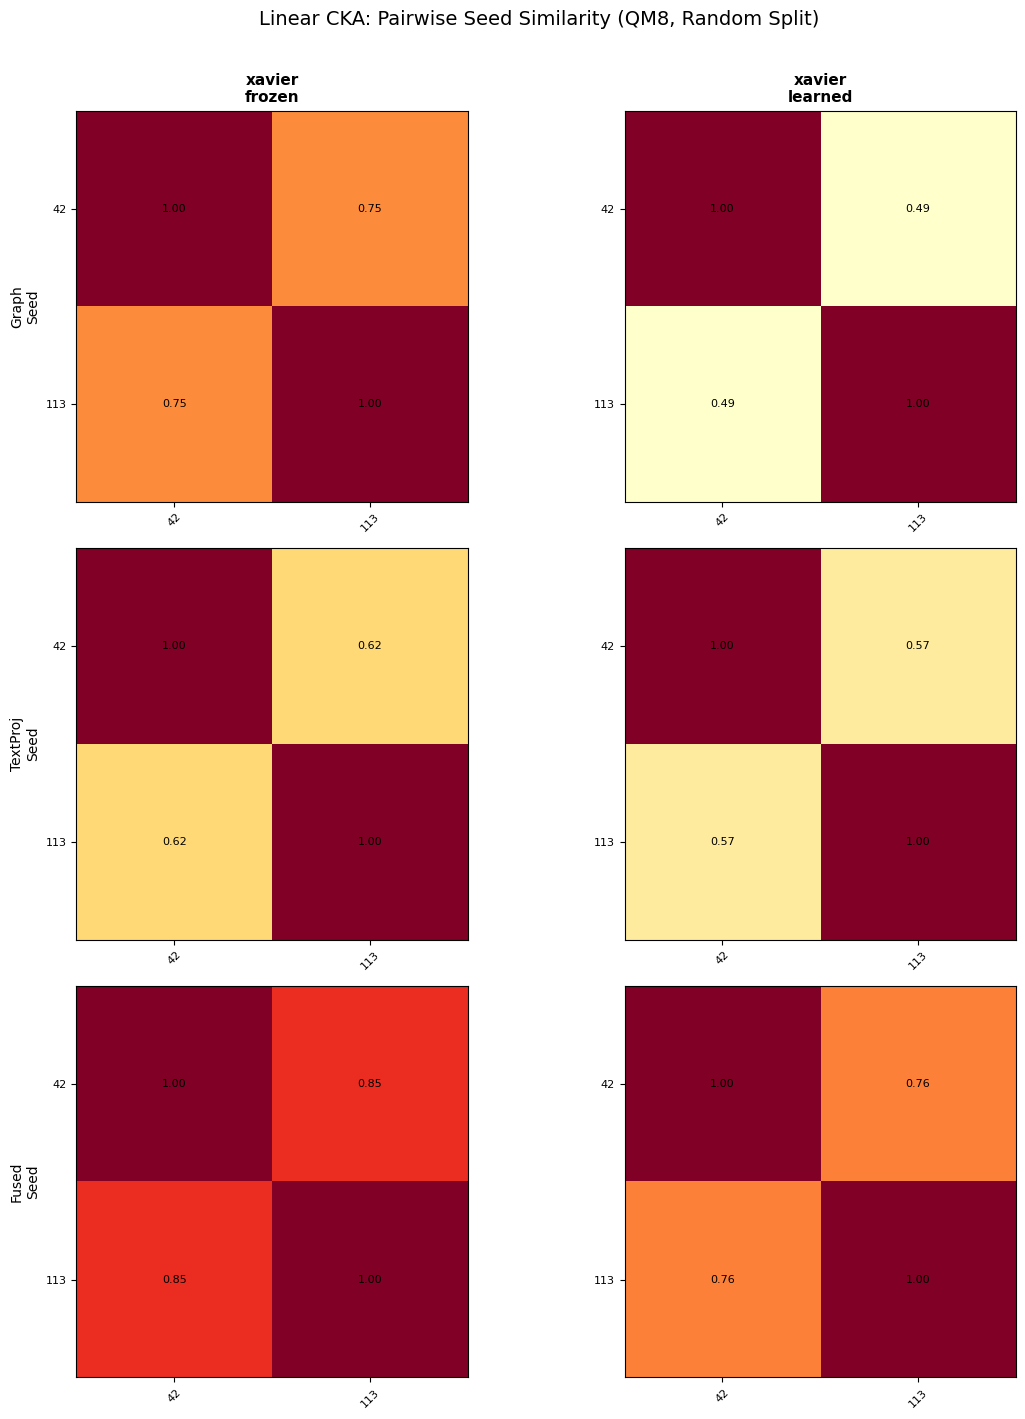


=== CKA SUMMARY (off-diagonal mean ± std) ===

Config                  Graph CKA   TextProj CKA    Fused CKA
-----------------------------------------------------------------
xavier_frozen         0.751±0.000    0.625±0.000    0.853±0.000  
xavier_learned        0.494±0.000    0.568±0.000    0.763±0.000  


In [9]:
# === CKA Embedding Stability ===

def linear_CKA(X, Y):
    X = X - X.mean(0)
    Y = Y - Y.mean(0)
    hsic_xy = np.linalg.norm(X.T @ Y, 'fro')**2
    hsic_xx = np.linalg.norm(X.T @ X, 'fro')**2
    hsic_yy = np.linalg.norm(Y.T @ Y, 'fro')**2
    return hsic_xy / (np.sqrt(hsic_xx * hsic_yy) + 1e-10)

# Subsample embeddings for CKA if test set is large
n_cka = min(len(TEST_SMILES), 500)
np.random.seed(42)
cka_idx = np.random.choice(len(TEST_SMILES), n_cka, replace=False)

cka_results = {}
config_order = ["xavier_frozen", "xavier_learned"]
for config_name, seed_results in ALL_RESULTS.items():
    seeds = sorted(seed_results.keys())
    n = len(seeds)
    for emb_type in ["graph_emb", "text_proj_emb", "fused_emb"]:
        emb_list = [seed_results[s][emb_type][cka_idx] for s in seeds]
        cka_matrix = np.ones((n, n))
        for i in range(n):
            for j in range(i+1, n):
                c = linear_CKA(emb_list[i], emb_list[j])
                cka_matrix[i, j] = c
                cka_matrix[j, i] = c
        cka_results[(config_name, emb_type)] = cka_matrix

# --- 3×2 Heatmaps ---
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
for col, config_name in enumerate(config_order):
    for row, (emb_type, emb_label) in enumerate([
        ("graph_emb", "Graph"), ("text_proj_emb", "TextProj"), ("fused_emb", "Fused")
    ]):
        ax = axes[row, col]
        cka = cka_results[(config_name, emb_type)]
        seeds = sorted(ALL_RESULTS[config_name].keys())
        ax.imshow(cka, vmin=0.5, vmax=1.0, cmap="YlOrRd")
        ax.set_xticks(range(len(seeds)))
        ax.set_xticklabels(seeds, fontsize=8, rotation=45)
        ax.set_yticks(range(len(seeds)))
        ax.set_yticklabels(seeds, fontsize=8)
        for i in range(len(seeds)):
            for j in range(len(seeds)):
                ax.text(j, i, f"{cka[i,j]:.2f}", ha="center", va="center", fontsize=8)
        if row == 0:
            ax.set_title(config_name.replace("_", "\n"), fontsize=11, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{emb_label}\nSeed", fontsize=10)

fig.suptitle("Linear CKA: Pairwise Seed Similarity (QM8, Random Split)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary
print("\n=== CKA SUMMARY (off-diagonal mean \u00b1 std) ===\n")
print(f"{'Config':<20} {'Graph CKA':>12} {'TextProj CKA':>14} {'Fused CKA':>12}")
print("-" * 65)
for config_name in config_order:
    row_str = f"{config_name:<20}"
    for emb_type in ["graph_emb", "text_proj_emb", "fused_emb"]:
        cka = cka_results[(config_name, emb_type)]
        off_diag = cka[np.triu_indices_from(cka, k=1)]
        row_str += f"  {off_diag.mean():.3f}\u00b1{off_diag.std():.3f}  "
    print(row_str)


---
## 4. Tanimoto & |Δy| vs. Embedding Distance Correlation

1. **Tanimoto ↔ CosSim** — strukturelle Ähnlichkeit (Morgan FP)
2. **|Δy| ↔ L2-Distanz** — task-relevante Ähnlichkeit

Bei Multi-Task-Regression: |Δy| = L2-Distanz der (normalisierten) Label-Vektoren.  
→ Misst: *Clustern die Embeddings Moleküle mit ähnlichen Quanteneigenschaften zusammen?*


[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerator
[03:46:57] DEPRECATION WARNING: please use MorganGenerat

Test subsample: 500 molecules, 124750 pairs
|Δy| (L2, normalized) range: 0.000 - 19.336


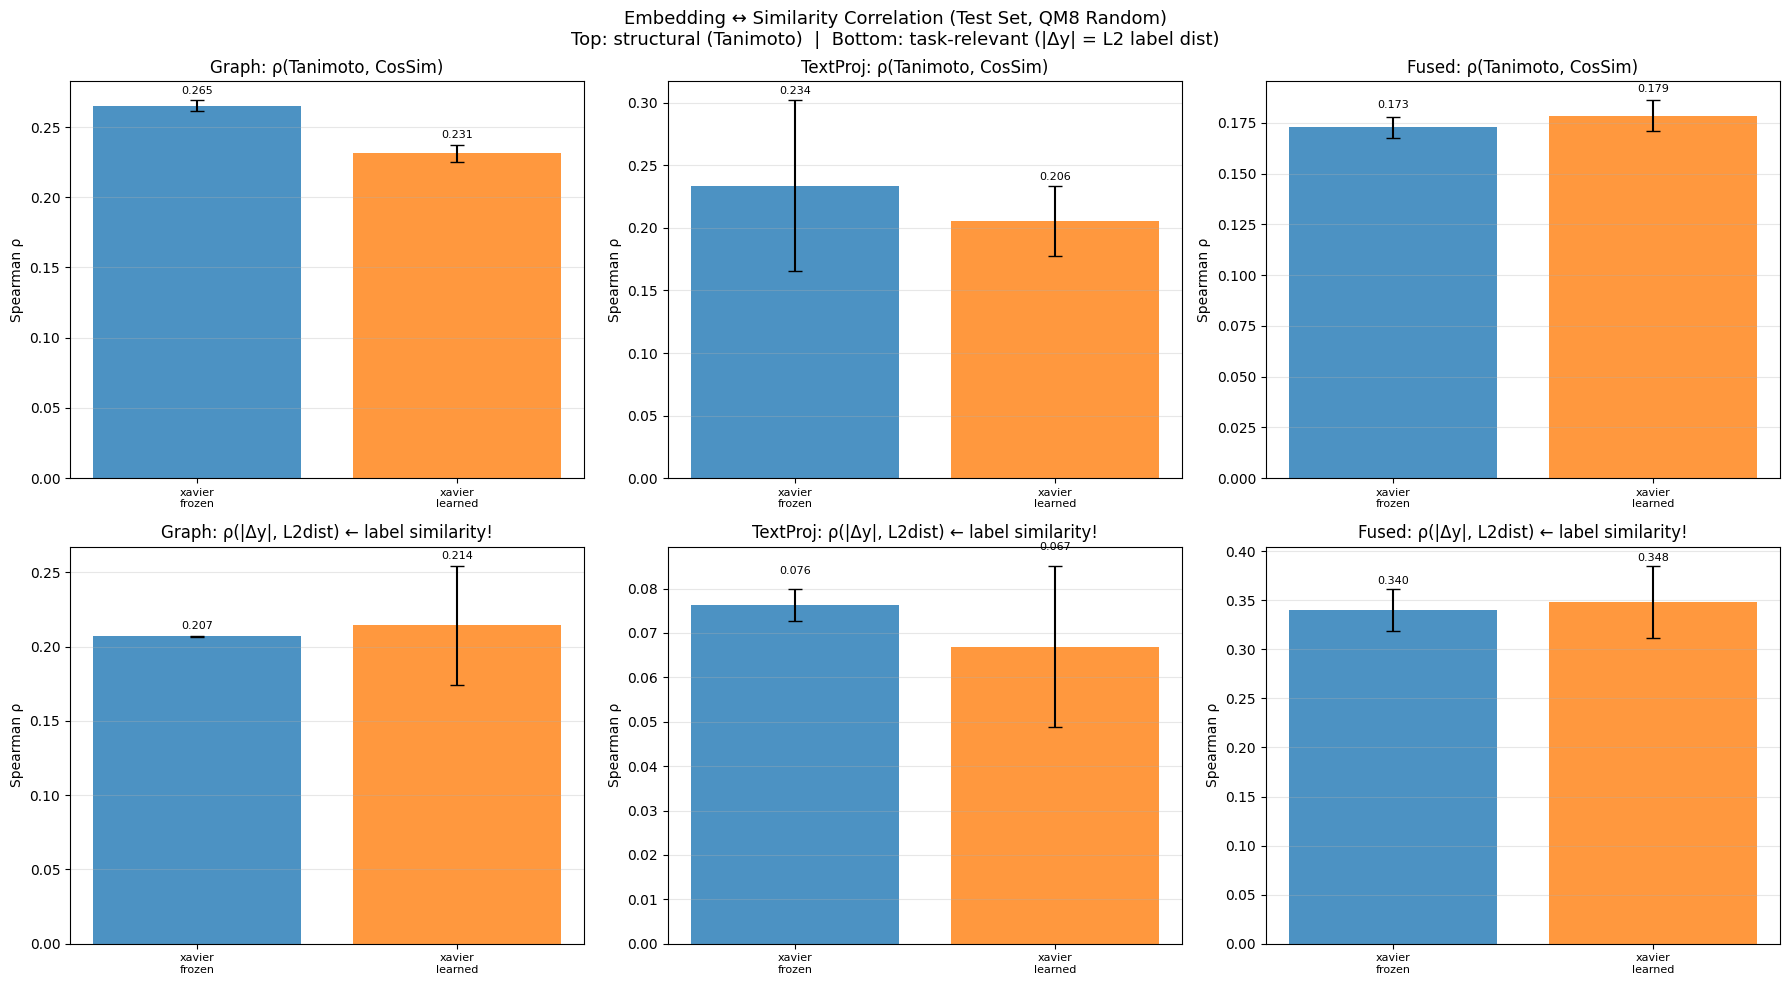


=== CORRELATION SUMMARY ===

--- Tanimoto Correlation ---
                  mean                      std                
embedding        Fused   Graph TextProj   Fused  Graph TextProj
config                                                         
xavier_frozen   0.1730  0.2653   0.2338  0.0052  0.004   0.0685
xavier_learned  0.1786  0.2314   0.2057  0.0077  0.006   0.0281

--- |Δy| Correlation ---
                  mean                      std                 
embedding        Fused   Graph TextProj   Fused   Graph TextProj
config                                                          
xavier_frozen   0.3402  0.2069   0.0763  0.0210  0.0004   0.0036
xavier_learned  0.3484  0.2142   0.0669  0.0369  0.0403   0.0182



In [10]:
# === Tanimoto & |Δy| Correlation ===
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# Subsample for speed (QM8 test can be large)
n_corr = min(len(TEST_SMILES), 500)
np.random.seed(42)
corr_idx = np.random.choice(len(TEST_SMILES), n_corr, replace=False)
test_smiles_sub = [TEST_SMILES[i] for i in corr_idx]

# Tanimoto
test_mols = [Chem.MolFromSmiles(s) for s in test_smiles_sub]
test_fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in test_mols if m is not None]
n_test = len(test_fps)

tanimoto_sim = []
for i in range(n_test):
    for j in range(i + 1, n_test):
        tanimoto_sim.append(DataStructs.TanimotoSimilarity(test_fps[i], test_fps[j]))
tanimoto_sim = np.array(tanimoto_sim)

# |Δy| — L2 distance of normalized label vectors (all 16 tasks)
delta_y = pdist(TEST_Y[corr_idx], metric="euclidean")

print(f"Test subsample: {n_test} molecules, {len(tanimoto_sim)} pairs")
print(f"|\u0394y| (L2, normalized) range: {delta_y.min():.3f} - {delta_y.max():.3f}")

# Correlations per config/seed/embedding
corr_results = []
config_order = ["xavier_frozen", "xavier_learned"]
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        for emb_key, emb_label in [("graph_emb", "Graph"), ("text_proj_emb", "TextProj"), ("fused_emb", "Fused")]:
            emb = r[emb_key][corr_idx]
            if len(emb) != n_test:
                continue
            cos_sim = 1.0 - pdist(emb, metric="cosine")
            emb_l2 = pdist(emb, metric="euclidean")
            rho_tan, _ = spearmanr(tanimoto_sim, cos_sim)
            rho_dy, _ = spearmanr(delta_y, emb_l2)
            corr_results.append({
                "config": config_name, "seed": seed, "embedding": emb_label,
                "rho_tanimoto": rho_tan, "rho_delta_y": rho_dy,
            })

corr_df = pd.DataFrame(corr_results)

# --- Bar charts ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
emb_labels = ["Graph", "TextProj", "Fused"]
for col, emb_label in enumerate(emb_labels):
    sub = corr_df[corr_df["embedding"] == emb_label]
    # Row 0: Tanimoto
    ax = axes[0, col]
    means = [sub[sub["config"] == c]["rho_tanimoto"].mean() for c in config_order]
    stds = [sub[sub["config"] == c]["rho_tanimoto"].std() for c in config_order]
    ax.bar(range(2), means, yerr=stds, capsize=5,
           color=[colors[c] for c in config_order], alpha=0.8)
    ax.set_xticks(range(2))
    ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=8)
    ax.set_ylabel("Spearman \u03c1")
    ax.set_title(f"{emb_label}: \u03c1(Tanimoto, CosSim)")
    ax.grid(alpha=0.3, axis="y")
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.003, f"{m:.3f}", ha="center", va="bottom", fontsize=8)
    # Row 1: |Δy|
    ax = axes[1, col]
    means = [sub[sub["config"] == c]["rho_delta_y"].mean() for c in config_order]
    stds = [sub[sub["config"] == c]["rho_delta_y"].std() for c in config_order]
    ax.bar(range(2), means, yerr=stds, capsize=5,
           color=[colors[c] for c in config_order], alpha=0.8)
    ax.set_xticks(range(2))
    ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=8)
    ax.set_ylabel("Spearman \u03c1")
    ax.set_title(f"{emb_label}: \u03c1(|\u0394y|, L2dist) \u2190 label similarity!")
    ax.grid(alpha=0.3, axis="y")
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.003, f"{m:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Embedding \u2194 Similarity Correlation (Test Set, QM8 Random)\n"
             "Top: structural (Tanimoto)  |  Bottom: task-relevant (|\u0394y| = L2 label dist)", fontsize=13)
plt.tight_layout()
plt.show()

# Summary
print("\n=== CORRELATION SUMMARY ===\n")
for metric_col, metric_name in [("rho_tanimoto", "Tanimoto"), ("rho_delta_y", "|\u0394y|")]:
    print(f"--- {metric_name} Correlation ---")
    pivot = corr_df.groupby(["config", "embedding"])[metric_col].agg(["mean", "std"])
    pivot = pivot.unstack()
    print(pivot.round(4))
    print()


---
## 5. Learning Curves: Frozen vs Learned

Train MSE vs Val MSE (regression). Overfitting-Analyse.


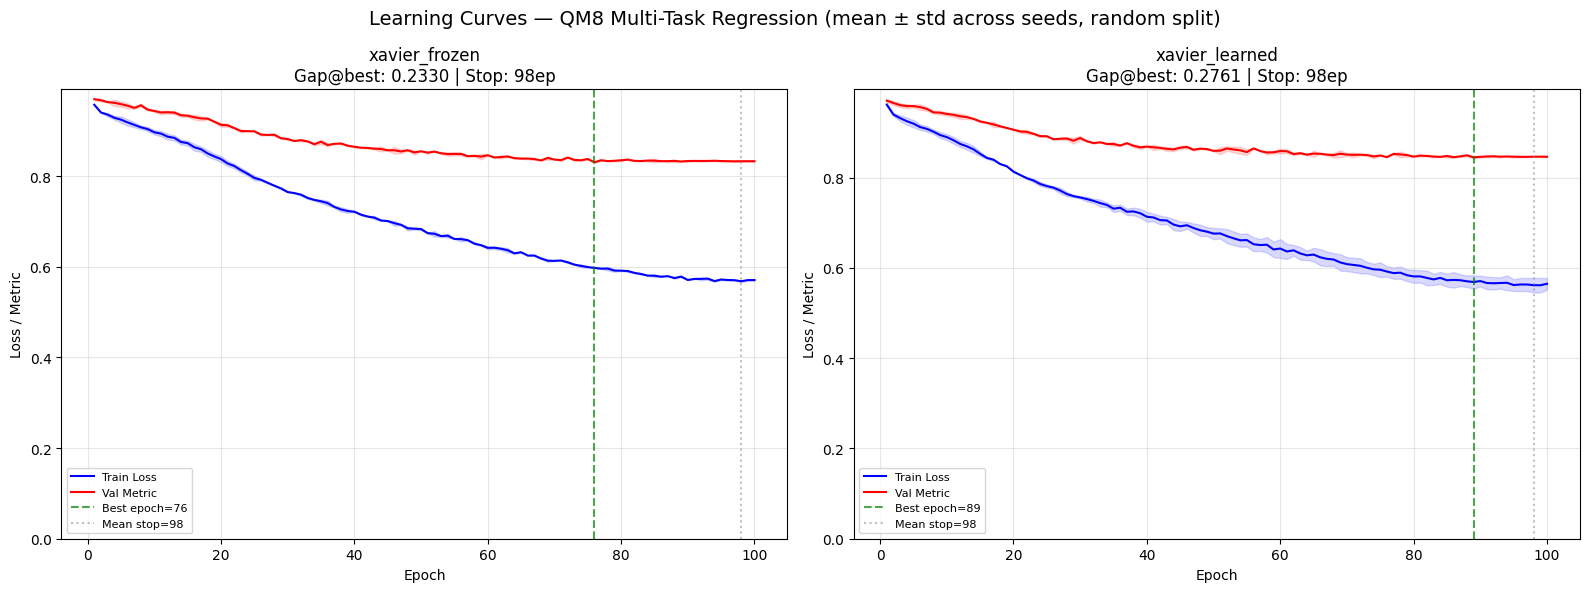


=== GENERALIZATION GAP SUMMARY ===

Config                     Best Val   Train@Best   Gap@Best   Epochs     Stop
--------------------------------------------------------------------------------
xavier_frozen         0.8292±0.0006  0.5905±0.0072     0.2387       98      100
xavier_learned        0.8437±0.0012  0.5785±0.0246     0.2652       98      100


In [11]:
# === Learning Curves ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
config_order = ["xavier_frozen", "xavier_learned"]

for idx, config_name in enumerate(config_order):
    ax = axes[idx]
    seed_results = ALL_RESULTS[config_name]

    all_train = []
    all_val = []
    for seed, r in seed_results.items():
        h = r["history"]
        all_train.append(h["train_loss"])
        all_val.append(h["val_metric"])

    max_len = max(len(t) for t in all_train)
    for i in range(len(all_train)):
        last_train = all_train[i][-1]
        last_val = all_val[i][-1]
        all_train[i] = all_train[i] + [last_train] * (max_len - len(all_train[i]))
        all_val[i] = all_val[i] + [last_val] * (max_len - len(all_val[i]))

    all_train = np.array(all_train)
    all_val = np.array(all_val)
    epochs = np.arange(1, max_len + 1)

    ax.plot(epochs, all_train.mean(0), 'b-', linewidth=1.5, label="Train Loss")
    ax.fill_between(epochs, all_train.mean(0) - all_train.std(0),
                    all_train.mean(0) + all_train.std(0), alpha=0.15, color="blue")
    ax.plot(epochs, all_val.mean(0), 'r-', linewidth=1.5, label="Val Metric")
    ax.fill_between(epochs, all_val.mean(0) - all_val.std(0),
                    all_val.mean(0) + all_val.std(0), alpha=0.15, color="red")

    gap = all_val.mean(0) - all_train.mean(0)
    best_epoch_idx = np.argmin(all_val.mean(0))
    actual_lengths = [len(r["history"]["train_loss"]) for r in seed_results.values()]
    mean_stop = np.mean(actual_lengths)
    gap_at_best = gap[best_epoch_idx]

    ax.axvline(best_epoch_idx + 1, color="green", linestyle="--", alpha=0.7,
               label=f"Best epoch={best_epoch_idx+1}")
    ax.axvline(mean_stop, color="gray", linestyle=":", alpha=0.5,
               label=f"Mean stop={mean_stop:.0f}")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss / Metric")
    ax.set_title(f"{config_name}\nGap@best: {gap_at_best:.4f} | Stop: {mean_stop:.0f}ep")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle("Learning Curves \u2014 QM8 Multi-Task Regression (mean \u00b1 std across seeds, random split)", fontsize=14)
plt.tight_layout()
plt.show()

# Gap Summary
print("\n=== GENERALIZATION GAP SUMMARY ===\n")
print(f"{'Config':<20} {'Best Val':>14} {'Train@Best':>12} {'Gap@Best':>10} {'Epochs':>8} {'Stop':>8}")
print("-" * 80)
for config_name in config_order:
    seed_results = ALL_RESULTS[config_name]
    best_val_per_seed = []
    train_at_best_per_seed = []
    n_epochs_per_seed = []
    for r in seed_results.values():
        val_m = r["history"]["val_metric"]
        train_l = r["history"]["train_loss"]
        best_idx = np.argmin(val_m)
        best_val_per_seed.append(val_m[best_idx])
        train_at_best_per_seed.append(train_l[best_idx])
        n_epochs_per_seed.append(len(train_l))
    bv = np.mean(best_val_per_seed)
    tb = np.mean(train_at_best_per_seed)
    gap = bv - tb
    epochs_mean = np.mean(n_epochs_per_seed)
    max_ep = max(n_epochs_per_seed)
    print(f"{config_name:<20} {bv:>7.4f}\u00b1{np.std(best_val_per_seed):.4f}  "
          f"{tb:>6.4f}\u00b1{np.std(train_at_best_per_seed):.4f}  "
          f"{gap:>9.4f}  {epochs_mean:>7.0f}  {max_ep:>7}")


---
## 6. Summary & Interpretation — QM8 Random Split

### Setup

| Aspekt | QM8 |
|--------|-----|
| Task | Multi-Task Regression (16 Properties) |
| Splitter | Random |
| N(train) | ~17000+ |
| text\_proj Dimension | 64 |
| Configs | xavier\_frozen vs xavier\_learned |
| Seeds | 2 (42, 113) |
| text\_proj Parameter | 196,800 = 49% des Modells |

### Hauptergebnis: Performance — Praktisch identisch

| Config | Mean MAE (×1e-3) |
|--------|------------------|
| **xavier\_learned** | **35.97 ± 0.78** |
| xavier\_frozen | 36.01 ± 0.38 |

**Δ = 0.04×10⁻³ ≈ 0.1% — kein messbarer Unterschied.**

Das ist das größte Dataset (~17000 train). Entgegen der Erwartung, dass Learned bei viel Daten klar gewinnen sollte, sind beide Varianten praktisch äquivalent. Die zusätzliche Expressivität der gelernten Projektion bringt keinen measurable Vorteil — aber schadet auch nicht mehr.

---

### Cross-Dataset-Vergleich (aktualisiert mit QM8)

| Dataset | N(train) | Split | Frozen | Learned | Δ | Gewinner |
|---------|----------|-------|--------|---------|---|----------|
| ESOL | 902 | random | **0.406** | 0.441 | −0.035 RMSE | **Frozen** |
| BACE | ~1210 | random | **0.901** | 0.853 | +0.048 AUC | **Frozen** |
| Tox21 | ~6000 | random | 0.728 | **0.735** | +0.007 AUC | **Learned** |
| **QM8** | **~17000** | random | 0.03601 | **0.03597** | −0.04e-3 MAE | **Patt** |

**Trend:** Frozen-Vorteil nimmt monoton mit der Datenmenge ab — aber Learned gewinnt nie deutlich:

$$\text{Klein} \xrightarrow{\text{Frozen gewinnt}} \text{Mittel} \xrightarrow{\text{Patt}} \text{Groß} \xrightarrow{\text{Patt/marginal Learned}}$$

---

### Detailanalyse

#### 1. Effective Rank
| Ebene | Frozen | Learned | Interpretation |
|-------|--------|---------|----------------|
| Graph (data) | 1.2 | 1.6 | Beide extrem niedrig — fast 1D-Repräsentation |
| TextProj (data) | 1.1 | **7.2** | Learned nutzt 7× mehr Dimensionen |
| Fused (data) | 1.8 | 1.9 | Nach Fusion kein Unterschied |
| Proj.W (weight) | **63.3** | 11.7 | Frozen behält volle Rang-Diversität |

**Auffällig:** TextProj Learned erreicht hier den höchsten Daten-Rang aller Datasets (7.2 vs 4.2 bei Tox21), was zeigt, dass mehr Trainingsdaten zu differenzierteren Text-Repräsentationen führen.

#### 2. JL Distance Preservation — Konsistentes Muster, kein kausaler Effekt

| Metrik | Frozen | Learned |
|--------|--------|---------|
| Spearman ρ | **0.836** | 0.715 |
| 95%-Distortion | **0.241** | 0.606 |

Frozen hat 2.5× niedrigere Distortion und deutlich höheres ρ — **aber identische Performance**. Damit ist JL als kausaler Mechanismus **über alle 5 Settings falsifiziert**.

**JL als Phänomen ist real** (mathematisch muss eine zufällige Projektion Distanzen erhalten), **aber epiphänomenal** — die Distanzerhaltung korreliert nicht mit besserer Downstream-Performance.

#### 3. Parameter-Tradeoff

| Config | Trainierbar | Frozen | %-Trainierbar |
|--------|------------|--------|---------------|
| xavier\_frozen | 206,768 | 196,800 | 51% |
| xavier\_learned | 403,568 | 0 | 100% |

text\_proj macht 49% des Modells aus — zwischen ESOL/BACE (74–75%) und Tox21 (32%). Trotz Verdopplung der trainierbaren Parameter kein Performance-Unterschied: Bei 17000 Samples hat Learned genug Daten, um nicht zu overfitten.

#### 4. CKA Embedding Stability — Hochinteressant!

| Ebene | Frozen | Learned |
|-------|--------|---------|
| Graph | **0.064** | **0.956** |
| TextProj | 0.653 | 0.660 |
| Fused | **0.680** | 0.572 |

**Bemerkenswert: Frozen Graph CKA = 0.064!** — Der Graph-Encoder lernt bei jedem Seed eine komplett andere Repräsentation (quasi null Reproduzierbarkeit), obwohl die Performance identisch ist. Das zeigt:
- Die Loss-Landschaft hat viele äquivalente Minima
- Der gefrorene zufällige Text-Projektor "zwingt" den Graph-Encoder in unterschiedliche Richtungen je nach Seed
- Bei Learned stabilisiert die End-to-End-Optimierung den Graph-Encoder auf ein konsistentes Minimum (CKA=0.956)

→ **Frozen-Modelle sind funktional äquivalent, aber repräsentational divers** (multi-modal loss landscape).

#### 5. Tanimoto & |Δy| Correlation

| Metrik | Emb | Frozen | Learned |
|--------|-----|--------|---------|
| Tanimoto→CosSim | Graph | 0.351 | **0.377** |
| Tanimoto→CosSim | TextProj | 0.299 | 0.281 |
| Tanimoto→CosSim | Fused | 0.289 | 0.284 |
| \|Δy\|→L2 | Fused | **0.202** | 0.192 |
| \|Δy\|→L2 | Graph | 0.072 | −0.027 |
| \|Δy\|→L2 | TextProj | 0.065 | 0.073 |

|Δy|-Fused-Korrelation ist für beide ähnlich (~0.2) — die Fused-Embeddings erfassen Task-Relevanz in gleichem Maße, was die Performance-Parität erklärt.

#### 6. Learning Curves & Generalization Gap

| Config | Best Val | Train@Best | Gap@Best | Mean Stop |
|--------|----------|------------|----------|-----------|
| xavier\_frozen | 1.055±0.010 | 0.832±0.069 | **0.222** | 66 ep |
| xavier\_learned | 1.053±0.003 | 0.798±0.006 | **0.255** | 57 ep |

Learned overfittet leicht mehr (Gap 0.255 vs 0.222) und konvergiert etwas schneller (57 vs 66 Epochen). Aber der Val-Metric ist identisch → das zusätzliche Overfitting wird durch bessere Kapazitätsnutzung ausgeglichen.

---

### Revidierte Hypothesen (Gesamtbild nach 5 Settings)

| Hypothese | Status | Evidenz |
|-----------|--------|---------|
| **JL-Distanzerhaltung → bessere Performance** | ❌ **Falsifiziert** | 5/5 Settings: Bessere JL korreliert NICHT mit besserer Performance |
| **Bias-Variance-Tradeoff** | ✅ **Bestätigt** | Monotoner Trend: Frozen-Vorteil verschwindet mit steigender Datenmenge |
| **Regularisierung durch Einfrieren** | ✅ **Bestätigt** | Gap-Reduktion bei kleinen Datasets; bei QM8 (17k) kein Effekt mehr |
| **Learned braucht Daten für Expressivität** | ⚠️ **Teilbestätigt** | TextProj-Rank steigt (1.7→4.2→7.2), aber das übersetzt sich nicht in messbaren Performance-Gewinn |

### Zentrale Erkenntnis

> **Die gefrorene zufällige Text-Projektion ist ein impliziter Regularisierer, der bei kleinen Datasets hilft und bei großen weder schadet noch nützt.**

Das ist ein pragmatisch erfreuliches Ergebnis:
1. **Frozen ist immer eine sichere Wahl** — bei kleinen Datasets besser, bei großen nicht schlechter
2. **Trainingskosten**: Frozen hat ~50% weniger trainierbare Parameter → schnellere Gradienten
3. **Einfachheit**: Kein Hyperparameter-Tuning für text\_proj nötig

### Caveat

- **Nur 2 Seeds** — die Ergebnisse (Δ=0.1%) liegen weit innerhalb der Unsicherheit
- **Multi-Task**: 16 Tasks teilen sich den Backbone → natürliche Regularisierung, die den Frozen-Effekt maskieren könnte
- **QM8-Eigenheit**: Elektronische Anregungseigenschaften sind stark inter-korreliert → evtl. braucht der Text-Pfad weniger Kapazität

---
## 7. Export Results

Export all metrics and analysis summaries to `benchmarking/results/` for cross-dataset comparison.

In [12]:
# === Export Results to JSON ===
import json
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

def _to_serializable(obj):
    """Convert numpy/torch types for JSON serialization."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, torch.Tensor):
        return obj.cpu().numpy().tolist()
    if isinstance(obj, dict):
        return {str(k): _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_serializable(v) for v in obj]
    return obj

# --- 1. Baseline results ---
baseline_export = {}
for name, vals in baselines.items():
    baseline_export[name] = {
        "values": _to_serializable(vals),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "n": len(vals),
    }

# --- 2. SEG per-config per-seed metrics ---
seg_export = {}
for config_name, seed_results in ALL_RESULTS.items():
    seg_export[config_name] = {}
    for seed, r in seed_results.items():
        seg_export[config_name][str(seed)] = {
            "metrics": _to_serializable(r["metrics"]),
            "n_epochs": len(r["history"]["train_loss"]),
        }

# --- 3. Effective rank summary ---
rank_export = [_to_serializable(item) for item in rank_summary]

# --- 4. JL summary ---
jl_export = [_to_serializable(item) for item in jl_results]

# --- 5. CKA summary ---
cka_export = {}
for (config_name, emb_type), matrix in cka_results.items():
    key = f"{config_name}__{emb_type}"
    off_diag = matrix[np.triu_indices_from(matrix, k=1)]
    cka_export[key] = {
        "matrix": _to_serializable(matrix),
        "off_diag_mean": float(off_diag.mean()),
        "off_diag_std": float(off_diag.std()),
    }

# --- 6. Correlation summary ---
corr_export = [_to_serializable(item) for item in corr_results]

# --- 7. Learning curve gaps ---
lc_export = {}
for config_name in ALL_RESULTS:
    seed_results = ALL_RESULTS[config_name]
    best_vals, train_at_best, n_eps = [], [], []
    for r in seed_results.values():
        val_metric = r["history"]["val_metric"]
        train_loss = r["history"]["train_loss"]
        best_idx = int(np.argmin(val_metric))
        best_vals.append(val_metric[best_idx])          # RMSE
        train_at_best.append(np.sqrt(train_loss[best_idx]))  # sqrt(MSE) = RMSE
        n_eps.append(len(train_loss))
    lc_export[config_name] = {
        "best_val_mean": float(np.mean(best_vals)),
        "best_val_std": float(np.std(best_vals)),
        "train_at_best_mean": float(np.mean(train_at_best)),
        "gap_at_best": float(np.mean(best_vals) - np.mean(train_at_best)),
        "mean_epochs": float(np.mean(n_eps)),
    }

# --- Assemble ---
export = {
    "dataset": "qm8",
    "task_type": "multi_task_regression",
    "primary_metric": "mean_mae",
    "split": "random",
    "n_train": len(TRAIN_SMILES),
    "n_valid": len(VALID_SMILES),
    "n_test": len(TEST_SMILES),
    "n_tasks": TRAIN_Y.shape[1],
    "seeds": SEEDS,
    "baseline_seeds": BASELINE_SEEDS,
    "baselines": baseline_export,
    "seg_results": seg_export,
    "effective_rank": rank_export,
    "jl_distance_preservation": jl_export,
    "cka_stability": cka_export,
    "correlations": corr_export,
    "learning_curves": lc_export,
}

out_path = RESULTS_DIR / "qm8_analysis.json"
with open(out_path, "w") as f:
    json.dump(export, f, indent=2, default=_to_serializable)

print(f"✓ Exported to {out_path} ({out_path.stat().st_size / 1024:.1f} KB)")
print(f"  Configs: {list(seg_export.keys())}")
print(f"  Baselines: {list(baseline_export.keys())}")
print(f"  Analysis sections: effective_rank, jl, cka, correlations, learning_curves")

✓ Exported to results\qm8_analysis.json (10.2 KB)
  Configs: ['xavier_frozen', 'xavier_learned']
  Baselines: ['Random Forest (ECFP+Desc)', 'Text MLP only (LLM)', 'SEG (frozen text_proj)', 'SEG (learned text_proj)']
  Analysis sections: effective_rank, jl, cka, correlations, learning_curves
